# Load Model & Data

In [1]:
import joblib
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# SHAP
import shap

# LOAD DATA
X_train = pd.read_csv("/content/X_train.csv")
X_test = pd.read_csv("/content/X_test.csv")

y_train = pd.read_csv("/content/y_train.csv")
y_test = pd.read_csv("/content/y_test.csv")

# LOAD BEST MODEL
rf_model = joblib.load("/content/random_forest.pkl")
print("Model & data loaded successfully.")

Model & data loaded successfully.


# Feature Importance

In [2]:
# =========================================================
# SECTION 2 — GLOBAL FEATURE IMPORTANCE
# =========================================================

feature_importance_df = pd.DataFrame({

    "Feature": rf_model.feature_names_in_,
    "Importance": rf_model.feature_importances_
})

feature_importance_df = (
    feature_importance_df
    .sort_values(
        by="Importance",
        ascending=False
    )
)

display(
    feature_importance_df.head(10)
)

,Feature,Importance
92,shipping_mode_risk,0.259342
85,days_for_shipment_(scheduled),0.240077
84,shipping_mode_Standard Class,0.187421
81,shipping_mode_First Class,0.165231
83,shipping_mode_Second Class,0.065365
82,shipping_mode_Same Day,0.020543
86,benefit_per_order,0.010624
89,order_month,0.006363
90,order_dayofweek,0.006358
88,sales,0.004556


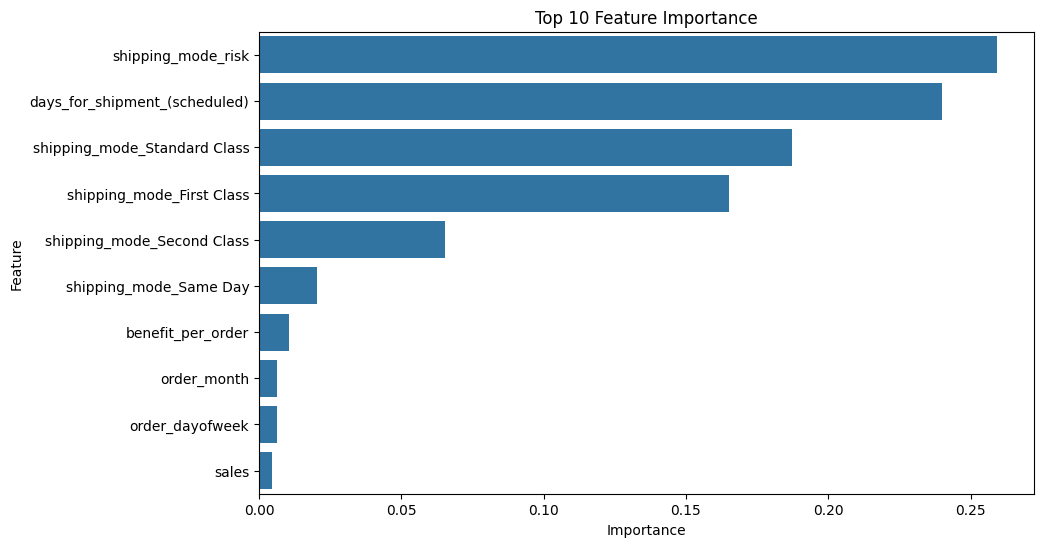

In [3]:
# =========================================================
# TOP 10 FEATURE IMPORTANCE PLOT
# =========================================================

top_features = (
    feature_importance_df
    .head(10)
)

plt.figure(figsize=(10, 6))

sns.barplot(

    data=top_features,
    x="Importance",
    y="Feature"

)

plt.title(
    "Top 10 Feature Importance"
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

# SHAP Analysis

In [4]:
# =========================================================
# 5. SHAP EXPLAINER
# =========================================================
X_shap_sample = X_test.sample(
    17000,
    random_state=42
)

explainer = shap.TreeExplainer(rf_model)

shap_values = explainer.shap_values(X_shap_sample)

print("=" * 60)
print("SHAP VALUES GENERATED")
print("=" * 60)

SHAP VALUES GENERATED


In [5]:
# =========================================================
# SECTION 3 — SHAP GLOBAL ANALYSIS
# =========================================================

explainer = shap.TreeExplainer(
    rf_model
)

shap_values = explainer.shap_values(
    X_shap_sample
)

In [10]:
print(type(shap_values))
print(np.array(shap_values).shape)

<class 'numpy.ndarray'>
(1000, 97, 2)


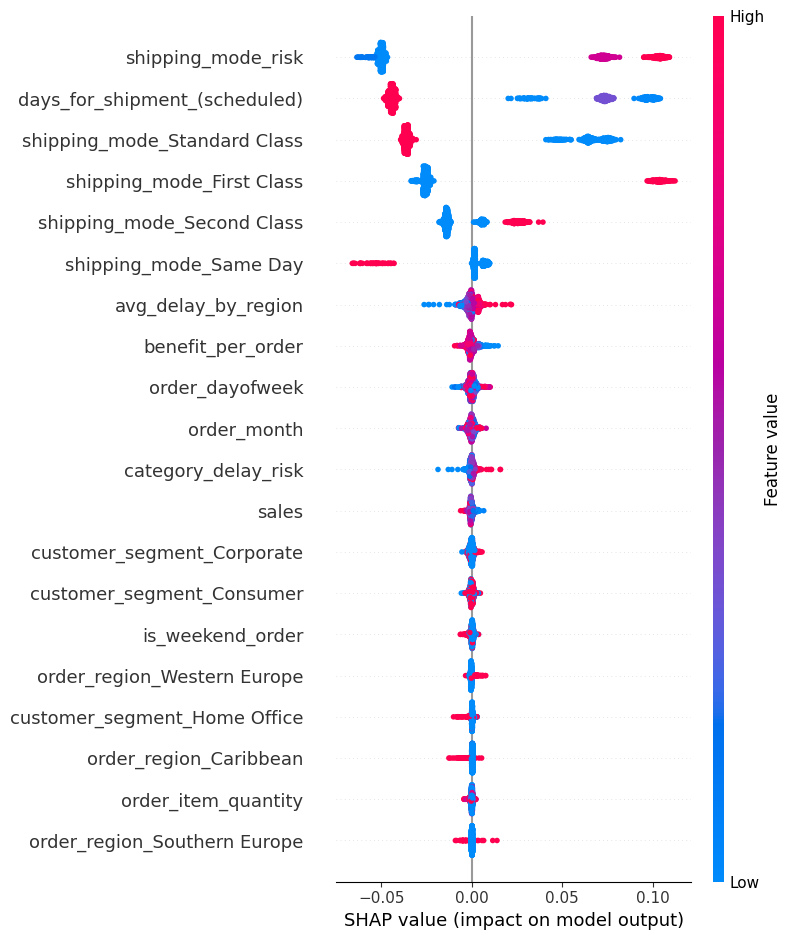

In [14]:
# =========================================================
# SHAP SUMMARY PLOT
# =========================================================

shap.summary_plot(
    shap_values[:, :, 1],
    X_shap_sample
)

# Region Analysis

In [15]:
# =========================================================
# SECTION 4 — REGION RISK ANALYSIS
# =========================================================

# Predict probability
y_test_prob = (
    rf_model
    .predict_proba(X_test)[:, 1]
)

# Create analysis dataframe
region_analysis_df = X_test.copy()

region_analysis_df["delay_risk_score"] = (
    y_test_prob * 100
)

# =========================================================
# AVERAGE RISK BY REGION
# =========================================================

region_risk_summary = (
    region_analysis_df.groupby("order_region")["delay_risk_score"]
    .mean().sort_values(ascending=False).reset_index()
    )

display(region_risk_summary)

ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- customer_late_rate
- customer_order_count


In [ ]:
# =========================================================
# REGION RISK VISUALIZATION
# =========================================================

plt.figure(figsize=(12, 6))

sns.barplot(

    data=region_risk_summary,
    x="delay_risk_score",
    y="order_region"

)

plt.title(
    "Average Delay Risk by Region"
)

plt.xlabel(
    "Average Risk Score"
)

plt.ylabel(
    "Region"
)

plt.show()

# Region Interpretation

In [ ]:
# =========================================================
# SECTION 5 — REGION DETAIL INTERPRETATION
# =========================================================

selected_region = "Western Europe"

selected_region_df = (

    region_analysis_df[
        region_analysis_df["order_region"] == selected_region]
    )

print(
    f"Total Shipment in {selected_region}:",
    len(selected_region_df)
)

print(
    f"Average Risk Score:",
    round(
        selected_region_df["delay_risk_score"].mean(), 2
        )
    )

In [ ]:
# SHAP ANALYSIS FOR SELECTED REGION
selected_region_index = (selected_region_df.index)

shap.summary_plot(
    shap_values[1][selected_region_index],
    X_test.loc[selected_region_index]
)

# Shipment Service Explain

In [ ]:
# SHIPMENT-LEVEL EXPLANATION
shipment_index = 10

print(
    "Predicted Risk Score:",
    round(y_test_prob[shipment_index] * 100, 2)
    )

In [ ]:
# LOCAL SHAP EXPLANATION
shap.force_plot(

    explainer.expected_value[1],
    shap_values[1][shipment_index],
    X_test.iloc[shipment_index],
    matplotlib=True

)

# Operational Summary

In [ ]:
# OPERATIONAL INSIGHT SUMMARY
# Most risky region
most_risky_region = (region_risk_summary.iloc[0])

print("Most Risky Region:")
print(most_risky_region["order_region"])

print(
    "Average Risk Score:",
    round(most_risky_region["delay_risk_score"], 2)
    )

In [ ]:
# =========================================================
# MOST IMPORTANT FEATURE
# =========================================================

most_important_feature = (feature_importance_df.iloc[0])

print("\nMost Important Feature:")
print(most_important_feature["Feature"])

print("Importance:",
    round(most_important_feature["Importance"], 4)
    )

NameError: name 'prediction_df' is not defined

In [ ]:
# =========================================================
# 15. HIGH RISK SHIPMENTS
# =========================================================

high_risk_df = prediction_df[
    prediction_df["risk_level"] == "HIGH"
]

print("=" * 60)
print("HIGH RISK SHIPMENTS")
print("=" * 60)

display(
    high_risk_df[
        [
            "risk_probability",
            "risk_level",
            "origin_context",
            "route_profile",
            "emission_profile",
            "sustainability_score",
            "recommendation"
        ]
    ].head(10)
)

In [ ]:
# =========================================================
# 16. RISK DISTRIBUTION
# =========================================================

prediction_df[
    "risk_level"
].value_counts().plot(
    kind="bar"
)

plt.title(
    "Risk Level Distribution"
)

plt.xlabel("Risk Level")

plt.ylabel("Count")

plt.show()

NameError: name 'prediction_df' is not defined

In [ ]:
# =========================================================
# 17. SUSTAINABILITY DISTRIBUTION
# =========================================================

prediction_df[
    "emission_profile"
].value_counts().plot(
    kind="bar"
)

plt.title(
    "Emission Profile Distribution"
)

plt.xlabel("Emission Profile")

plt.ylabel("Count")

plt.show()

In [ ]:
# =========================================================
# 18. SAVE EXPLAINABILITY OUTPUT
# =========================================================

prediction_df.to_csv(
    "../data/processed/decision_support_output.csv",
    index=False
)

print("=" * 60)
print("DECISION SUPPORT OUTPUT SAVED")
print("=" * 60)

NameError: name 'prediction_df' is not defined

# API Enrichment Layer

In [ ]:
eyJvcmciOiI1YjNjZTM1OTc4NTExMTAwMDFjZjYyNDgiLCJpZCI6IjBhMjVmOGQ0NDhlMzRkM2Y4OTI0YzBhNjg3OGRmMDY5IiwiaCI6Im11cm11cjY0In0=